In [1]:
import pandas as pd
import glob
import os

folder_path = "C:\\Users\\15145\\Downloads\\Stat Canada Data\\Altogether"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for file in all_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Merge all dataframes
merged_df = pd.concat(df_list, ignore_index=True)

print(f"Total files merged: {len(all_files)}")
print(f"Final shape: {merged_df.shape}")
merged_df.head()

Total files merged: 22
Final shape: (2484374, 60)


,REC_NUM,SURVYEAR,SURVMNTH,LFSSTAT,PROV,CMA,AGE_12,AGE_6,GENDER,MARSTAT,...,LKATADS,LKANSADS,LKOTHERN,PRIORACT,YNOLOOK,TLOLOOK,SCHOOLN,EFAMTYPE,AGYOWNK,FINALWT
0,1,2024,1,1,35,4,5,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3,1.0,403
1,2,2024,1,4,24,0,12,NaN,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN,140
2,3,2024,1,1,35,0,6,NaN,1,6,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,NaN,378
3,4,2024,1,4,47,0,4,NaN,1,6,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,18,NaN,222
4,5,2024,1,1,10,0,1,2.0,1,6,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4,NaN,34


In [3]:
unemp_df = df[['PROV','DURUNEMP','FLOWUNEM' ]]

In [4]:
filtered_df = unemp_df[unemp_df['PROV'] == 35]

print(f"Original shape: {unemp_df.shape}")
print(f"Filtered shape: {filtered_df.shape}")
filtered_df.head()

Original shape: (112068, 3)
Filtered shape: (36042, 3)


,PROV,DURUNEMP,FLOWUNEM
3,35,NaN,NaN
5,35,NaN,NaN
10,35,NaN,NaN
12,35,NaN,NaN
15,35,NaN,NaN


In [5]:
DURUNEMP_COUNTS = df['DURUNEMP'].value_counts()
sum1 = DURUNEMP_COUNTS.sum()

print(DURUNEMP_COUNTS)
print(sum1)

DURUNEMP
4.0     534
8.0     328
2.0     296
6.0     224
12.0    223
       ... 
96.0      1
67.0      1
61.0      1
74.0      1
84.0      1
Name: count, Length: 79, dtype: int64
4103


In [6]:
FLOWUNEM_COUNTS = df['FLOWUNEM'].value_counts()
sum2 = FLOWUNEM_COUNTS.sum()

print(FLOWUNEM_COUNTS)
print(sum2)

FLOWUNEM
2.0    1241
7.0     714
6.0     698
5.0     669
4.0     337
3.0     280
1.0     164
8.0     116
Name: count, dtype: int64
4219


In [7]:
columns_to_keep = [
   'SURVYEAR','SURVMNTH', 'PROV', 'LFSSTAT', 'DURUNEMP', 'FLOWUNEM', 'UNEMFTPT',
    'LKPUBAG', 'LKEMPLOY', 'LKRELS', 'LKATADS', 'LKANSADS', 'LKOTHERN'
]

# Filter for PROV = 35 AND LFSSTAT = 3 (Unemployed)
unemployment_df = merged_df[(merged_df['PROV'] == 35) & (merged_df['LFSSTAT'] == 3)][columns_to_keep]

print(f"Filtered shape: {unemployment_df.shape}")
unemployment_df.head()

Filtered shape: (34690, 13)


,SURVYEAR,SURVMNTH,PROV,LFSSTAT,DURUNEMP,FLOWUNEM,UNEMFTPT,LKPUBAG,LKEMPLOY,LKRELS,LKATADS,LKANSADS,LKOTHERN
11,2024,1,35,3,NaN,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
127,2024,1,35,3,6.0,3.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN
281,2024,1,35,3,25.0,2.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN
378,2024,1,35,3,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0
786,2024,1,35,3,10.0,2.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN


In [8]:
unemployment_df

,SURVYEAR,SURVMNTH,PROV,LFSSTAT,DURUNEMP,FLOWUNEM,UNEMFTPT,LKPUBAG,LKEMPLOY,LKRELS,LKATADS,LKANSADS,LKOTHERN
11,2024,1,35,3,NaN,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
127,2024,1,35,3,6.0,3.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN
281,2024,1,35,3,25.0,2.0,1.0,NaN,NaN,1.0,1.0,1.0,NaN
378,2024,1,35,3,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0
786,2024,1,35,3,10.0,2.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484090,2024,12,35,3,4.0,5.0,2.0,NaN,1.0,NaN,NaN,NaN,NaN
2484119,2024,12,35,3,18.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0
2484213,2024,12,35,3,46.0,2.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0
2484316,2024,12,35,3,10.0,4.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN


In [9]:
employment_columns = [
    # Base info
    'PROV', 'SURVYEAR', 'SURVMNTH',
    
    # Employment status
    'LFSSTAT', 'MJH', 'EVERWORK',
    
    # Job characteristics
    'COWMAIN', 'NAICS_21', 'NOC_10', 'NOC_43', 'PERMTEMP', 'TENURE',
    
    # Hours
    'FTPTMAIN', 'UHRSMAIN', 'AHRSMAIN', 'UTOTHRS', 'ATOTHRS',
    'PAIDOT', 'UNPAIDOT', 'XTRAHRS', 'WKSAWAY',
    
    # Wages
    'HRLYEARN',
    
    # Other
    'WHYPT', 'WHYLEFTN'
]

# Filter for PROV = 35 AND LFSSTAT = 1 or 2 (Employed)
employment_df = merged_df[
    (merged_df['PROV'] == 35) & 
    (merged_df['LFSSTAT'].isin([1, 2]))  # 1=Employed at work, 2=Employed absent
][employment_columns]

In [10]:
employment_df

,PROV,SURVYEAR,SURVMNTH,LFSSTAT,MJH,EVERWORK,COWMAIN,NAICS_21,NOC_10,NOC_43,...,AHRSMAIN,UTOTHRS,ATOTHRS,PAIDOT,UNPAIDOT,XTRAHRS,WKSAWAY,HRLYEARN,WHYPT,WHYLEFTN
0,35,2024,1,1,1.0,NaN,2.0,7.0,1.0,4.0,...,400.0,400.0,400.0,0.0,0.0,0.0,NaN,7212.0,NaN,NaN
2,35,2024,1,1,1.0,NaN,2.0,6.0,1.0,4.0,...,400.0,400.0,400.0,0.0,0.0,0.0,NaN,5800.0,NaN,NaN
6,35,2024,1,1,1.0,NaN,2.0,8.0,10.0,42.0,...,400.0,400.0,400.0,0.0,0.0,0.0,NaN,2450.0,NaN,NaN
7,35,2024,1,1,1.0,NaN,2.0,6.0,8.0,35.0,...,420.0,450.0,420.0,0.0,0.0,0.0,NaN,2800.0,NaN,NaN
25,35,2024,1,1,1.0,NaN,2.0,15.0,2.0,9.0,...,400.0,400.0,400.0,0.0,0.0,0.0,NaN,2500.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484350,35,2024,12,1,2.0,NaN,2.0,11.0,8.0,38.0,...,425.0,710.0,625.0,0.0,0.0,0.0,NaN,2500.0,NaN,NaN
2484354,35,2024,12,1,1.0,NaN,2.0,11.0,8.0,36.0,...,500.0,500.0,500.0,0.0,0.0,0.0,NaN,2600.0,NaN,NaN
2484366,35,2024,12,1,1.0,NaN,2.0,6.0,8.0,35.0,...,350.0,350.0,350.0,0.0,0.0,0.0,NaN,4400.0,NaN,NaN
2484368,35,2024,12,1,1.0,NaN,2.0,8.0,10.0,43.0,...,415.0,415.0,415.0,0.0,0.0,0.0,NaN,1830.0,NaN,NaN


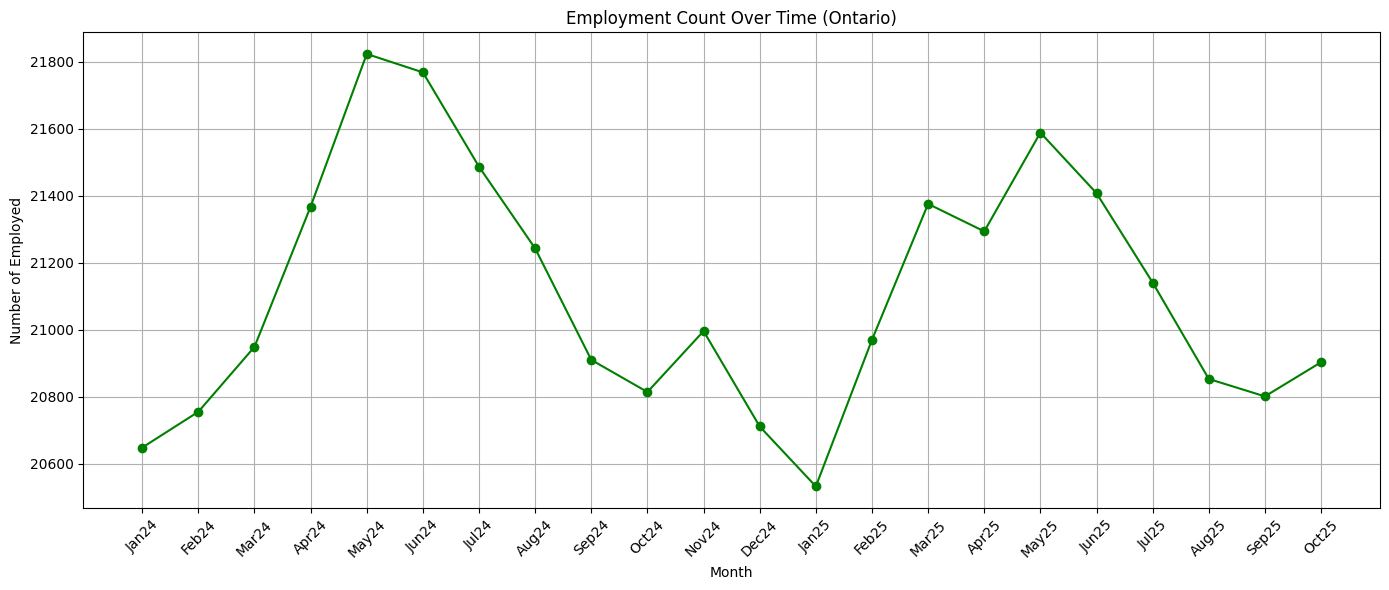

   SURVYEAR  SURVMNTH date_label  count
0      2024         1      Jan24  20648
1      2024         2      Feb24  20755
2      2024         3      Mar24  20949
3      2024         4      Apr24  21368
4      2024         5      May24  21824
5      2024         6      Jun24  21769
6      2024         7      Jul24  21487
7      2024         8      Aug24  21243
8      2024         9      Sep24  20910
9      2024        10      Oct24  20814


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by year and month
monthly_employment = employment_df.groupby(['SURVYEAR', 'SURVMNTH']).size().reset_index(name='count')

# Create proper date labels (like "Jan24", "Feb24")
monthly_employment['date_label'] = pd.to_datetime(
    monthly_employment[['SURVYEAR', 'SURVMNTH']].rename(
        columns={'SURVYEAR': 'year', 'SURVMNTH': 'month'}
    ).assign(day=1)
).dt.strftime('%b%y')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(range(len(monthly_employment)), monthly_employment['count'], marker='o', color='green')
plt.title('Employment Count Over Time (Ontario)')
plt.xlabel('Month')
plt.ylabel('Number of Employed')
plt.xticks(range(len(monthly_employment)), monthly_employment['date_label'], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Check the data
print(monthly_employment[['SURVYEAR', 'SURVMNTH', 'date_label', 'count']].head(10))

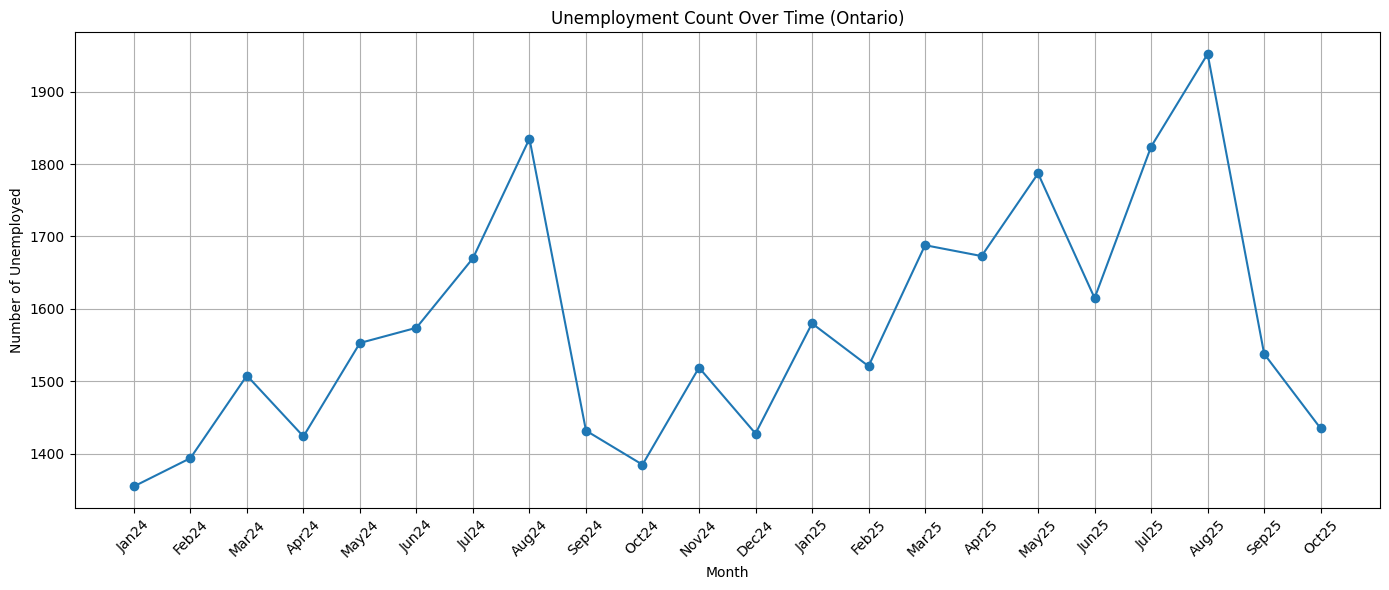

   SURVYEAR  SURVMNTH date_label  count
0      2024         1      Jan24   1355
1      2024         2      Feb24   1394
2      2024         3      Mar24   1508
3      2024         4      Apr24   1424
4      2024         5      May24   1553
5      2024         6      Jun24   1574
6      2024         7      Jul24   1670
7      2024         8      Aug24   1835
8      2024         9      Sep24   1432
9      2024        10      Oct24   1385


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by year and month
monthly_unemployment = unemployment_df.groupby(['SURVYEAR', 'SURVMNTH']).size().reset_index(name='count')

# Create proper date labels (like "Jan24", "Feb24")
monthly_unemployment['date_label'] = pd.to_datetime(
    monthly_unemployment[['SURVYEAR', 'SURVMNTH']].rename(
        columns={'SURVYEAR': 'year', 'SURVMNTH': 'month'}
    ).assign(day=1)
).dt.strftime('%b%y')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(range(len(monthly_unemployment)), monthly_unemployment['count'], marker='o')
plt.title('Unemployment Count Over Time (Ontario)')
plt.xlabel('Month')
plt.ylabel('Number of Unemployed')
plt.xticks(range(len(monthly_unemployment)), monthly_unemployment['date_label'], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Check the data
print(monthly_unemployment[['SURVYEAR', 'SURVMNTH', 'date_label', 'count']].head(10))

In [13]:
#WoodGreen Employed Data
import pandas as pd

# Load the CSV
df_monthly_2024 = pd.read_csv('monthly_registrations_2024.csv', 
                            index_col=0,  # Use first column as index
                            parse_dates=True)  # Parse the date column

monthly_registrations = df_monthly_2024.squeeze()  # Converts single-column DataFrame to Series

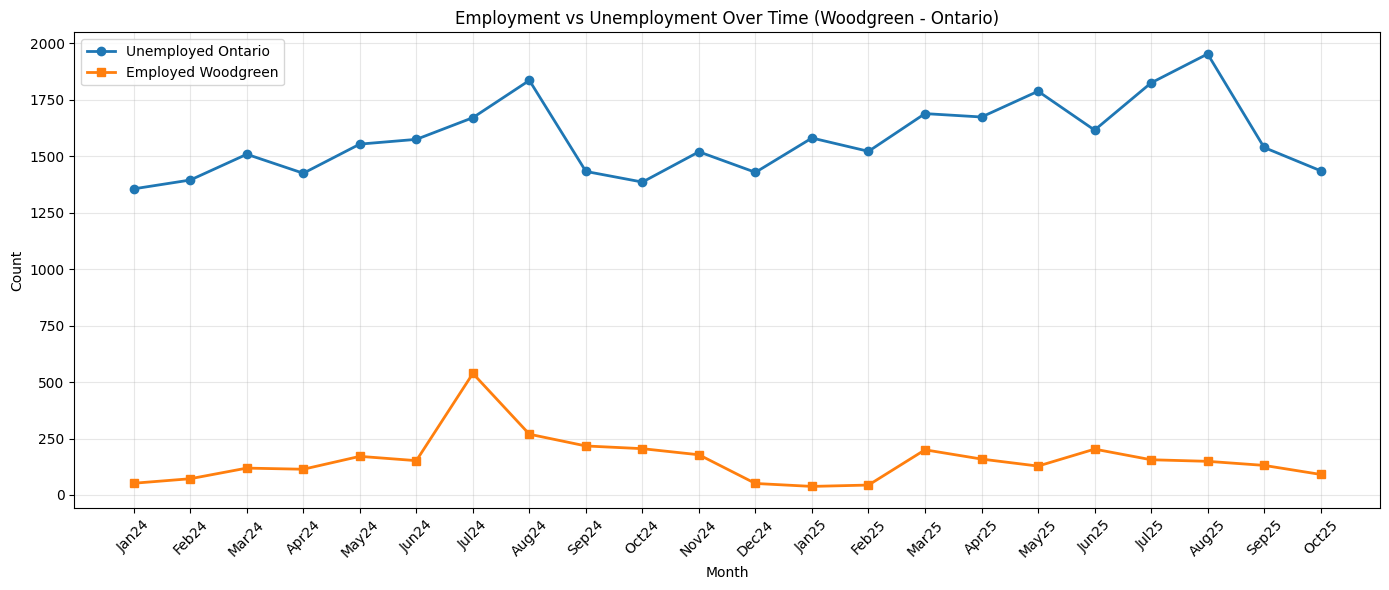

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your employment data
df_monthly_2024 = pd.read_csv('monthly_registrations_2024.csv', 
                               index_col=0, 
                               parse_dates=True)
employment_series = df_monthly_2024.squeeze()

# Your unemployment data processing
monthly_unemployment = unemployment_df.groupby(['SURVYEAR', 'SURVMNTH']).size().reset_index(name='count')
monthly_unemployment['date_label'] = pd.to_datetime(
    monthly_unemployment[['SURVYEAR', 'SURVMNTH']].rename(
        columns={'SURVYEAR': 'year', 'SURVMNTH': 'month'}
    ).assign(day=1)
).dt.strftime('%b%y')

# Create the combined plot
plt.figure(figsize=(14, 6))

# Plot unemployment
plt.plot(range(len(monthly_unemployment)), 
         monthly_unemployment['count'], 
         marker='o', 
         label='Unemployed Ontario',
         linewidth=2)

# Plot employment (align with unemployment x-axis)
plt.plot(range(len(employment_series)), 
         employment_series.values, 
         marker='s', 
         label='Employed Woodgreen',
         linewidth=2)

plt.title('Employment vs Unemployment Over Time (Woodgreen - Ontario)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(range(len(monthly_unemployment)), monthly_unemployment['date_label'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

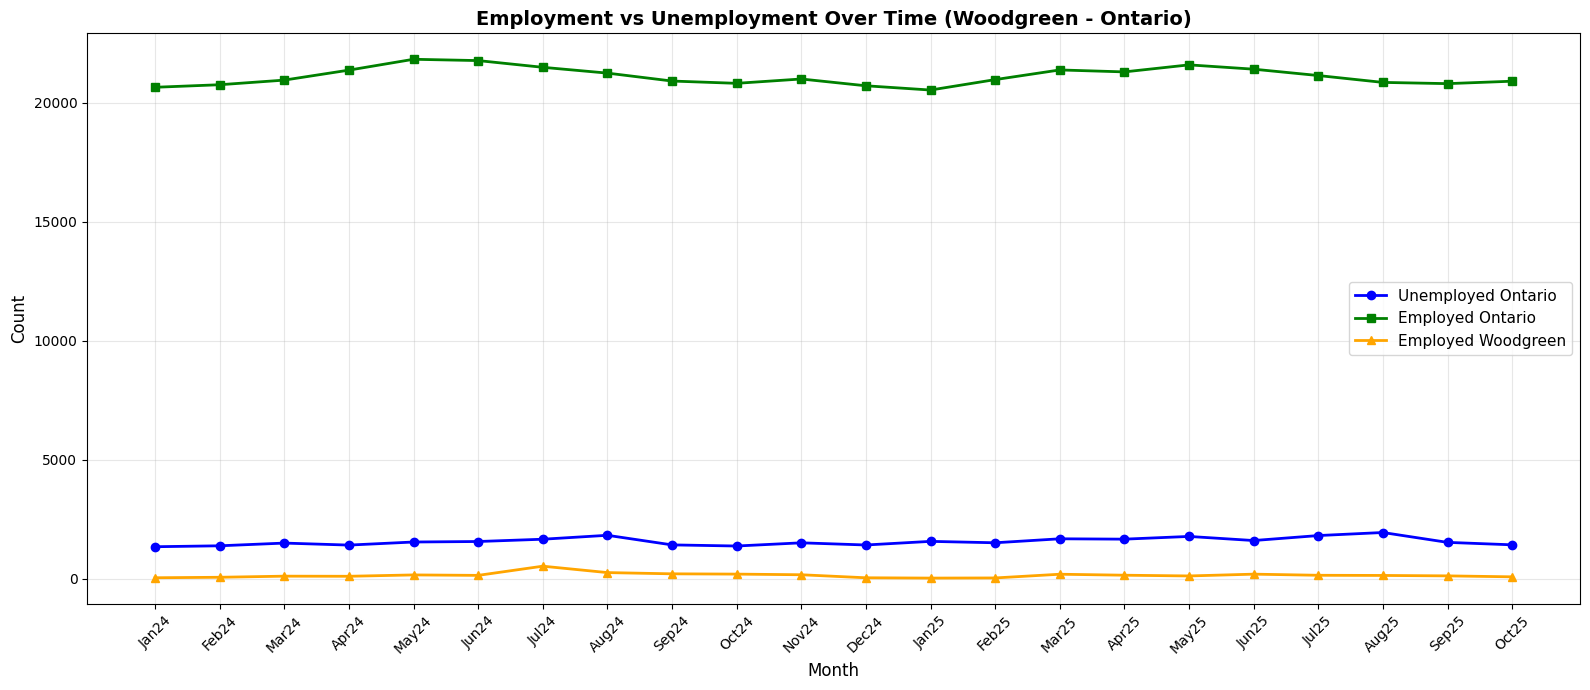

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Load Woodgreen employment data
df_monthly_2024 = pd.read_csv('monthly_registrations_2024.csv', 
                               index_col=0, 
                               parse_dates=True)
woodgreen_employment = df_monthly_2024.squeeze()

# Ontario unemployment data
monthly_unemployment = unemployment_df.groupby(['SURVYEAR', 'SURVMNTH']).size().reset_index(name='count')
monthly_unemployment['date_label'] = pd.to_datetime(
    monthly_unemployment[['SURVYEAR', 'SURVMNTH']].rename(
        columns={'SURVYEAR': 'year', 'SURVMNTH': 'month'}
    ).assign(day=1)
).dt.strftime('%b%y')

# Ontario employment data
monthly_employment = employment_df.groupby(['SURVYEAR', 'SURVMNTH']).size().reset_index(name='count')
monthly_employment['date_label'] = pd.to_datetime(
    monthly_employment[['SURVYEAR', 'SURVMNTH']].rename(
        columns={'SURVYEAR': 'year', 'SURVMNTH': 'month'}
    ).assign(day=1)
).dt.strftime('%b%y')

# Create the combined plot
plt.figure(figsize=(16, 7))

# Plot all three lines
plt.plot(range(len(monthly_unemployment)), 
         monthly_unemployment['count'], 
         marker='o', 
         label='Unemployed Ontario',
         linewidth=2,
         color='blue')

plt.plot(range(len(monthly_employment)), 
         monthly_employment['count'], 
         marker='s', 
         label='Employed Ontario',
         linewidth=2,
         color='green')

plt.plot(range(len(woodgreen_employment)), 
         woodgreen_employment.values, 
         marker='^', 
         label='Employed Woodgreen',
         linewidth=2,
         color='orange')

plt.title('Employment vs Unemployment Over Time (Woodgreen - Ontario)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(range(len(monthly_unemployment)), monthly_unemployment['date_label'], rotation=45)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



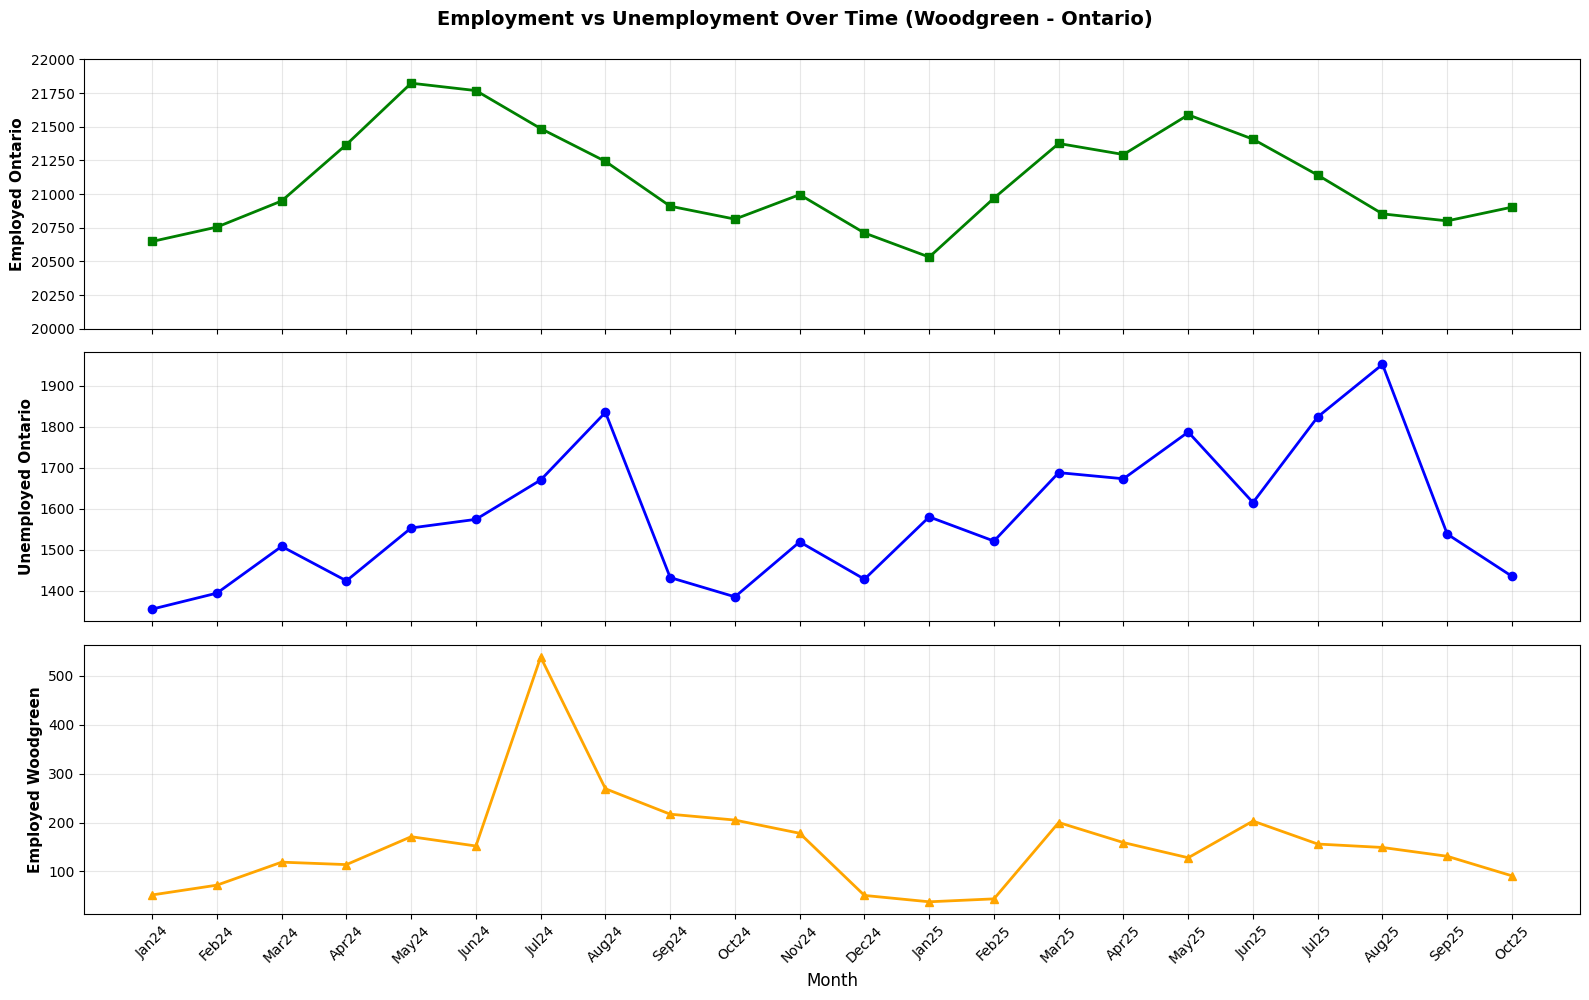

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data loading code here...

# Create stacked subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Employment Ontario (top)
ax1.plot(range(len(monthly_employment)), 
         monthly_employment['count'], 
         marker='s', 
         linewidth=2,
         color='green')
ax1.set_ylabel('Employed Ontario', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(20000, 22000)  # Adjust to show variation

# Unemployment Ontario (middle)
ax2.plot(range(len(monthly_unemployment)), 
         monthly_unemployment['count'], 
         marker='o', 
         linewidth=2,
         color='blue')
ax2.set_ylabel('Unemployed Ontario', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Woodgreen (bottom)
ax3.plot(range(len(woodgreen_employment)), 
         woodgreen_employment.values, 
         marker='^', 
         linewidth=2,
         color='orange')
ax3.set_ylabel('Employed Woodgreen', fontsize=11, fontweight='bold')
ax3.set_xlabel('Month', fontsize=12)
ax3.grid(True, alpha=0.3)

# Set x-axis labels only on bottom plot
ax3.set_xticks(range(len(monthly_unemployment)))
ax3.set_xticklabels(monthly_unemployment['date_label'], rotation=45)

# Overall title
fig.suptitle('Employment vs Unemployment Over Time (Woodgreen - Ontario)', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

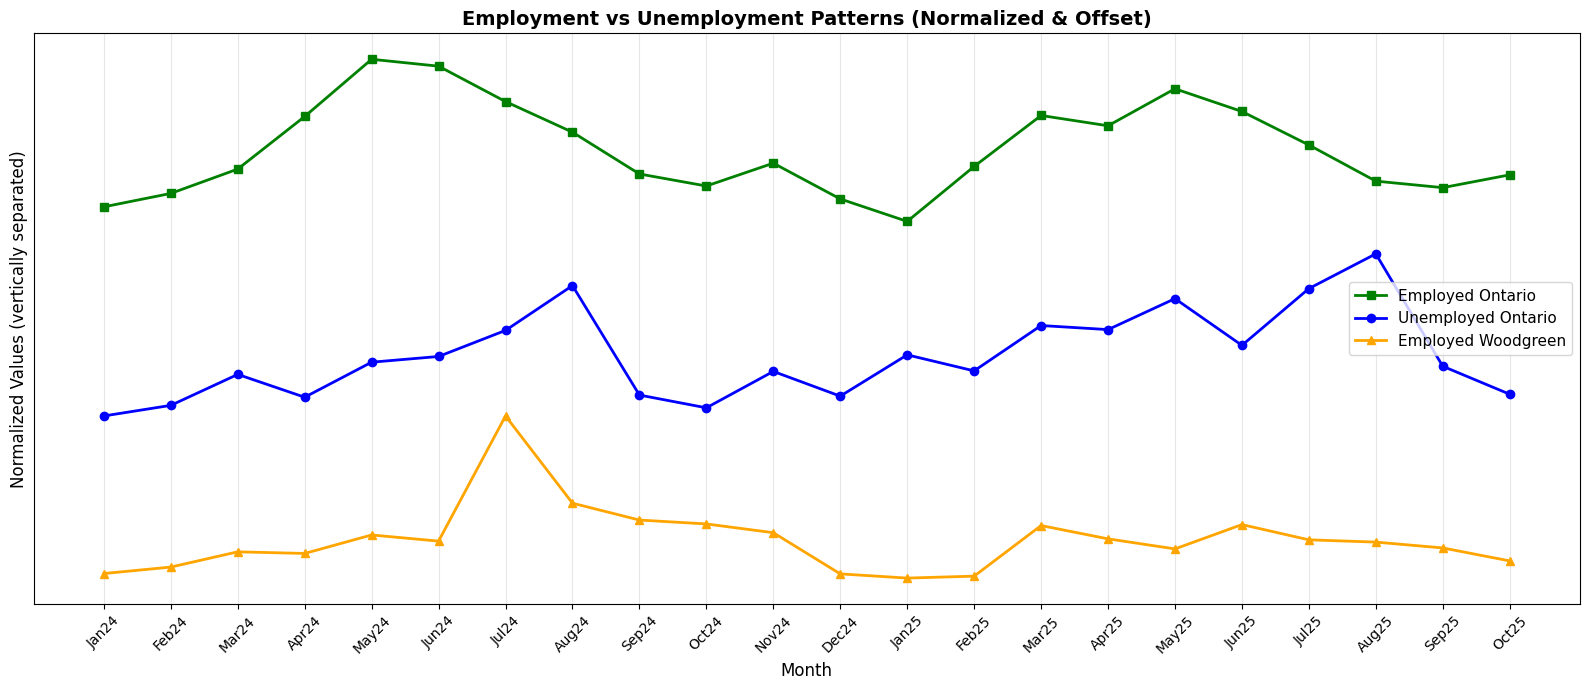

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Normalize each series to 0-1
scaler = MinMaxScaler()
employment_norm = scaler.fit_transform(monthly_employment[['count']]).flatten()
unemployment_norm = scaler.fit_transform(monthly_unemployment[['count']]).flatten()
woodgreen_norm = scaler.fit_transform(woodgreen_employment.values.reshape(-1, 1)).flatten()

# Add vertical offsets to maintain order
employment_shifted = employment_norm + 2.2  # Top
unemployment_shifted = unemployment_norm + 1.0  # Middle
woodgreen_shifted = woodgreen_norm + 0.0  # Bottom

# Plot
plt.figure(figsize=(16, 7))

plt.plot(range(len(employment_shifted)), 
         employment_shifted, 
         marker='s', 
         label='Employed Ontario',
         linewidth=2,
         color='green')

plt.plot(range(len(unemployment_shifted)), 
         unemployment_shifted, 
         marker='o', 
         label='Unemployed Ontario',
         linewidth=2,
         color='blue')

plt.plot(range(len(woodgreen_shifted)), 
         woodgreen_shifted, 
         marker='^', 
         label='Employed Woodgreen',
         linewidth=2,
         color='orange')

plt.title('Employment vs Unemployment Patterns (Normalized & Offset)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Normalized Values (vertically separated)', fontsize=12)
plt.xticks(range(len(monthly_unemployment)), monthly_unemployment['date_label'], rotation=45)

# Remove y-axis ticks since they're not meaningful with offsets
plt.yticks([])

plt.legend(fontsize=11, loc='right')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()